In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/naiyakhalid/flood-prediction-dataset/sample_submission.csv
/kaggle/input/datasets/naiyakhalid/flood-prediction-dataset/flood.csv
/kaggle/input/datasets/naiyakhalid/flood-prediction-dataset/train.csv
/kaggle/input/datasets/naiyakhalid/flood-prediction-dataset/test.csv


In [2]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings = warnings.filterwarnings('ignore')

# EDA

**Exploratory Data Analysis (EDA) is the initial step in a data science workflow where the dataset is examined to understand its structure, patterns, and quality before building any machine learning model. It involves summarizing the data using statistical measures, identifying missing values, analyzing distributions of variables, and studying relationships between features and the target variable**

In [3]:
# lets load the dataset
df = pd.read_csv('/kaggle/input/datasets/naiyakhalid/flood-prediction-dataset/flood.csv')
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [4]:
df.columns


Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='object')

In [5]:
df.shape

(50000, 21)

In [6]:
df.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


In [7]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns:")
print(numeric_cols)

Numeric columns:
Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='object')


In [8]:
# lets check if any columns need to be encoded
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index([], dtype='object')


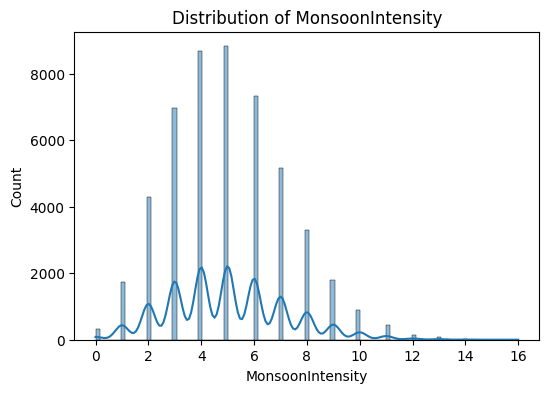

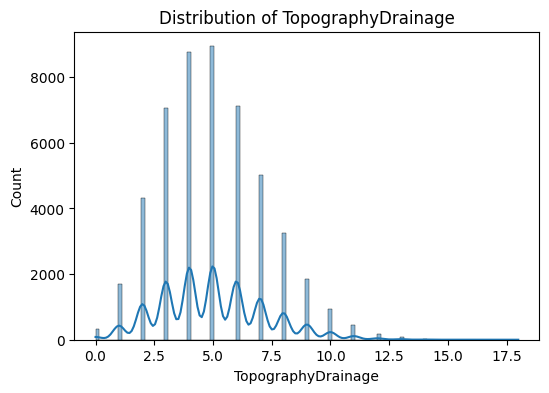

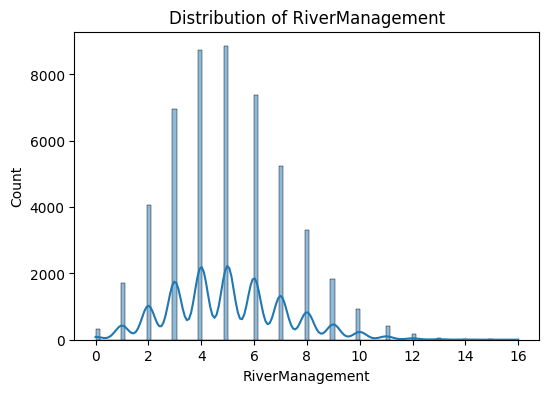

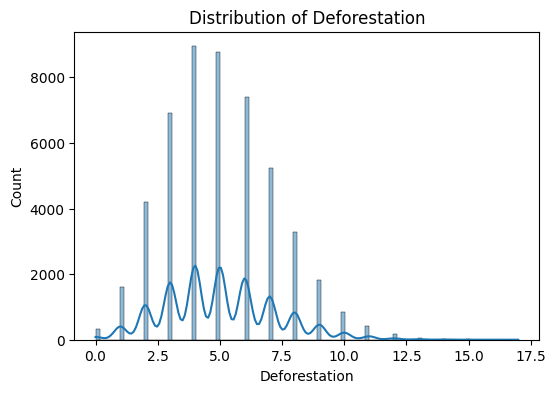

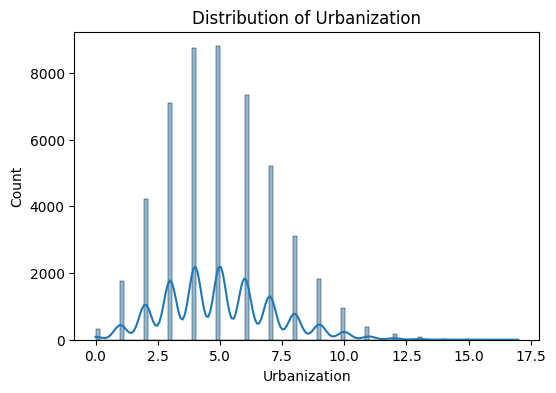

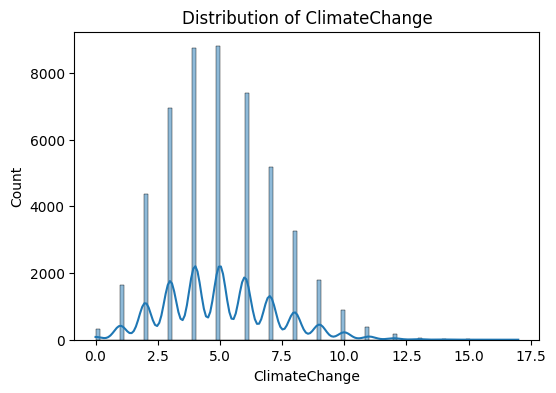

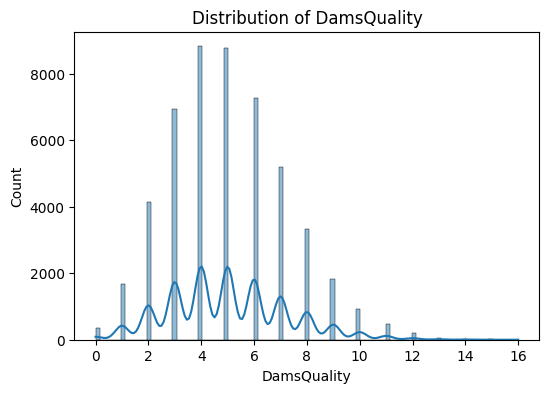

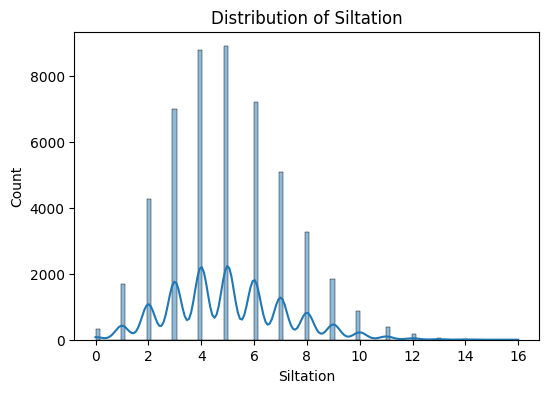

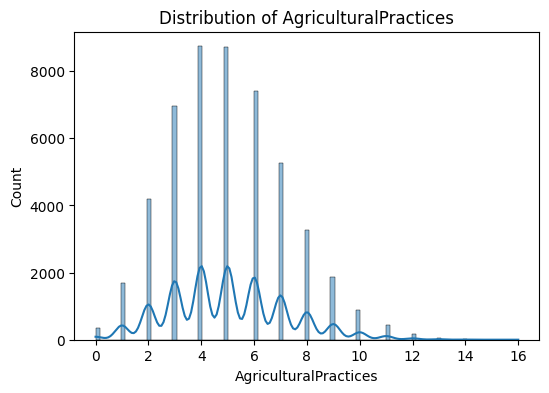

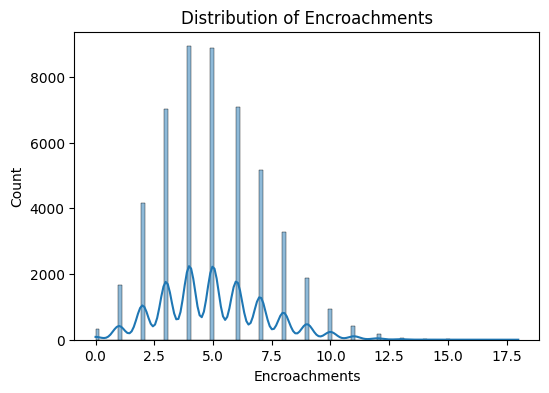

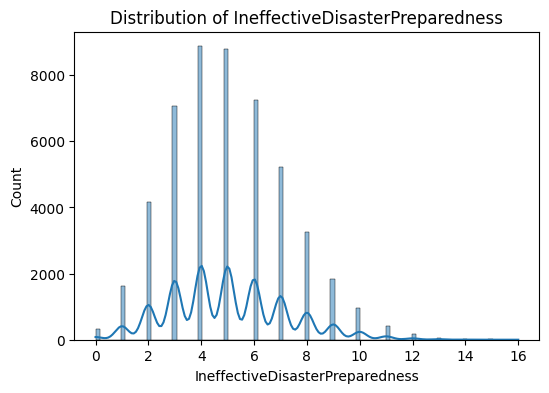

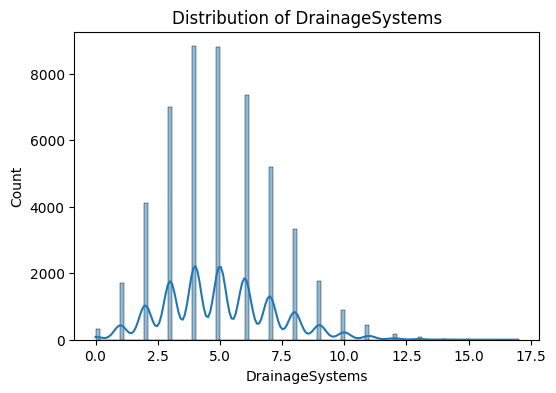

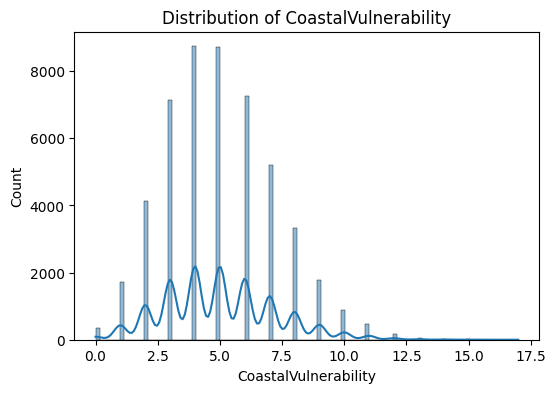

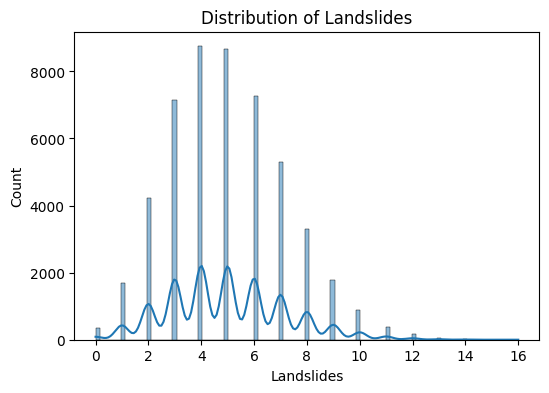

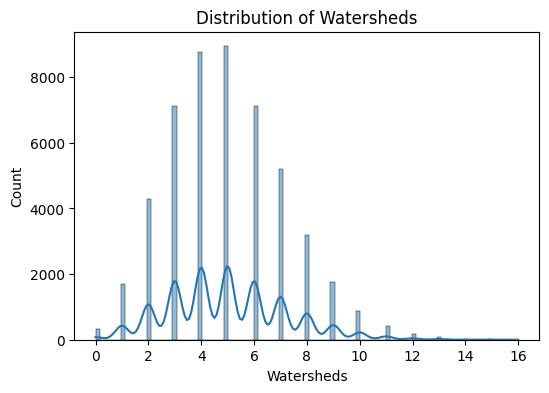

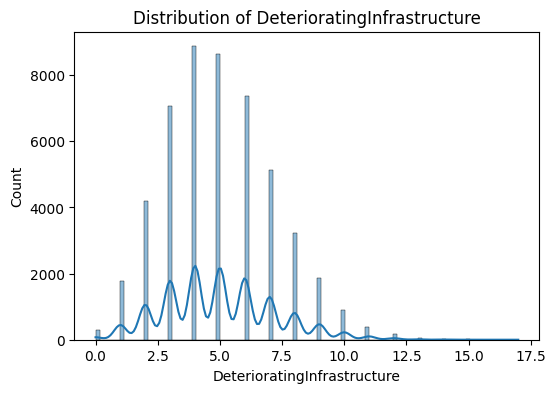

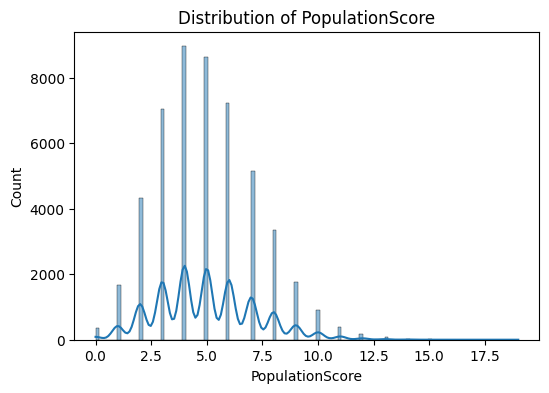

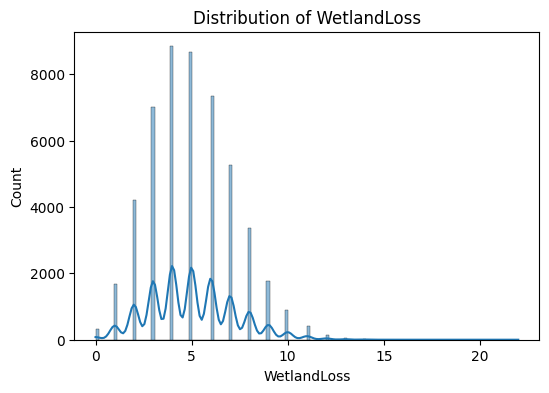

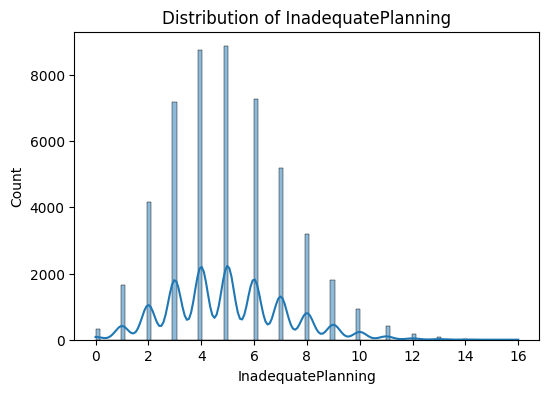

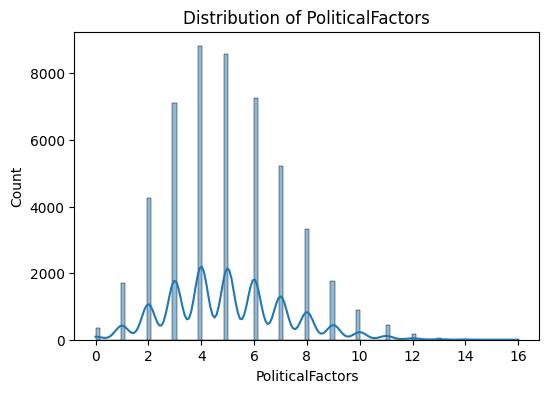

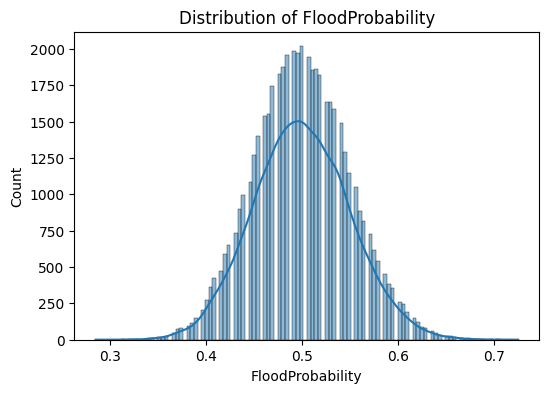

In [9]:
# now i am showing the distributions of each features

for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

** In Conclusion

My data is already in a nice condition to work . The distributions was equally distributed and there is no outliers**

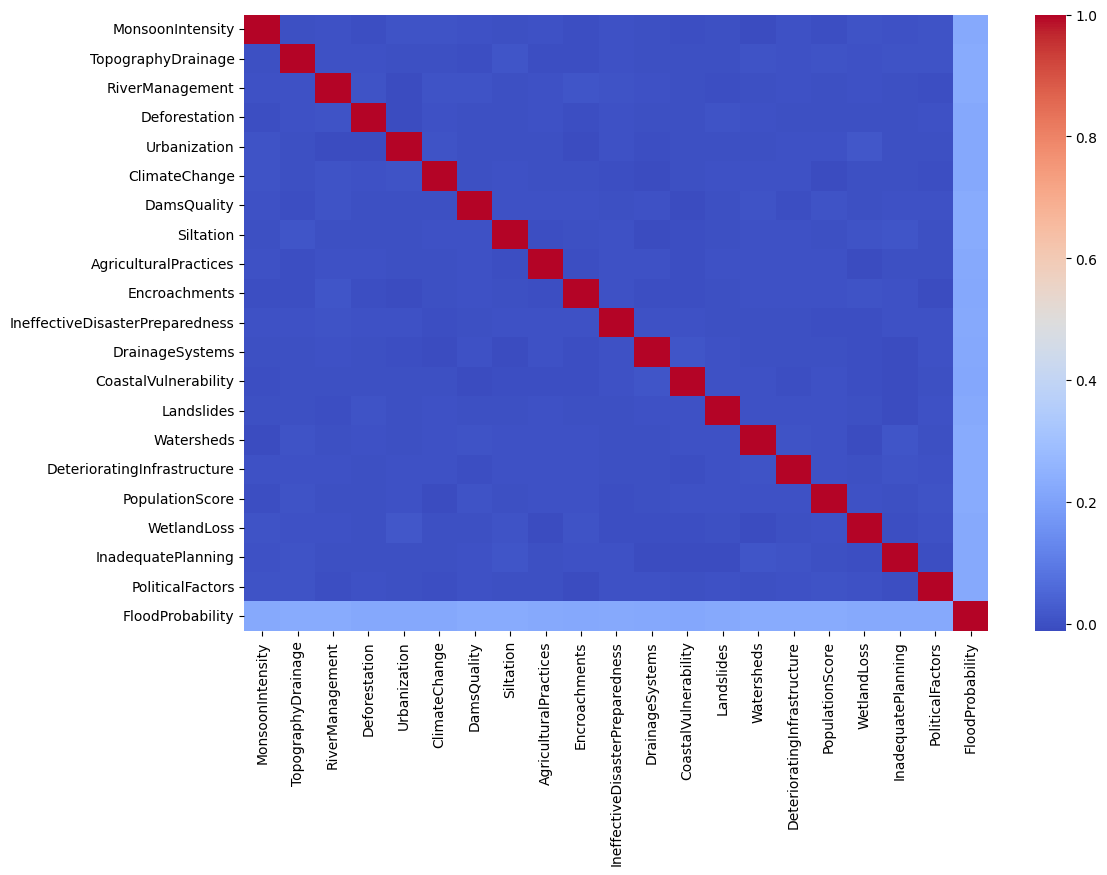

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

**The heatmap might be confusing but it was correct . It showed that my target variable floodprobability was nearly 40-45% correlated to all columns**

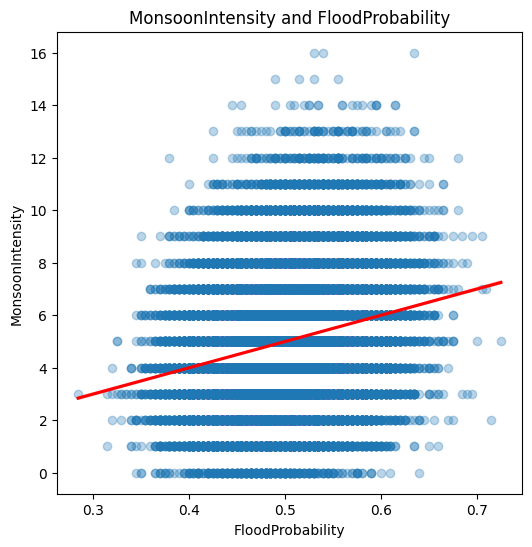

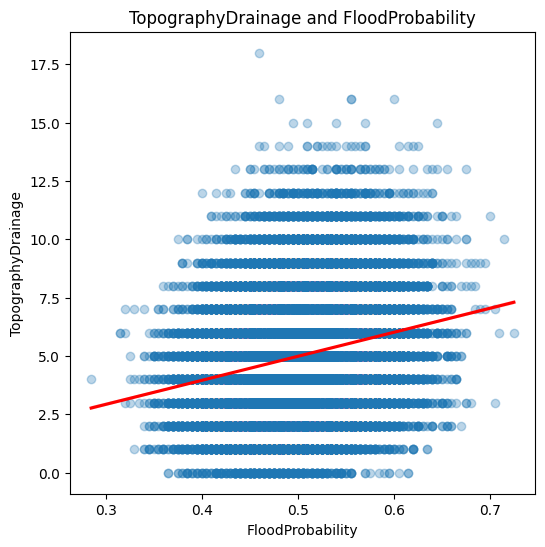

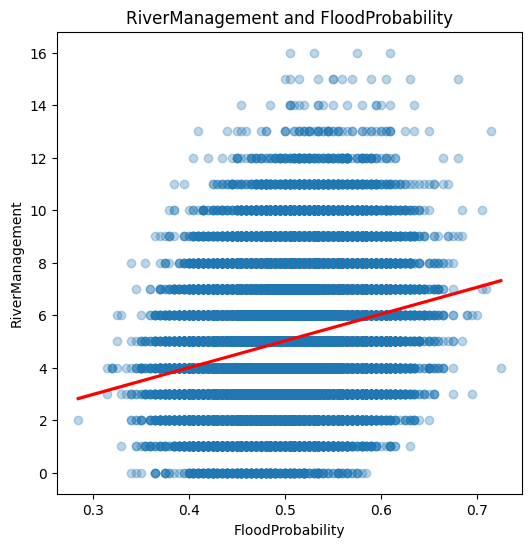

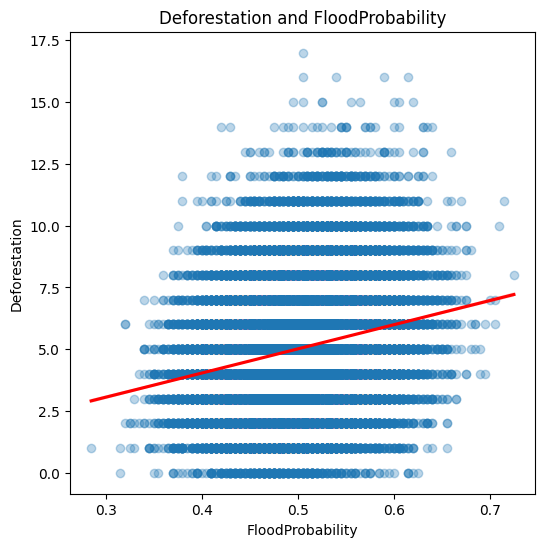

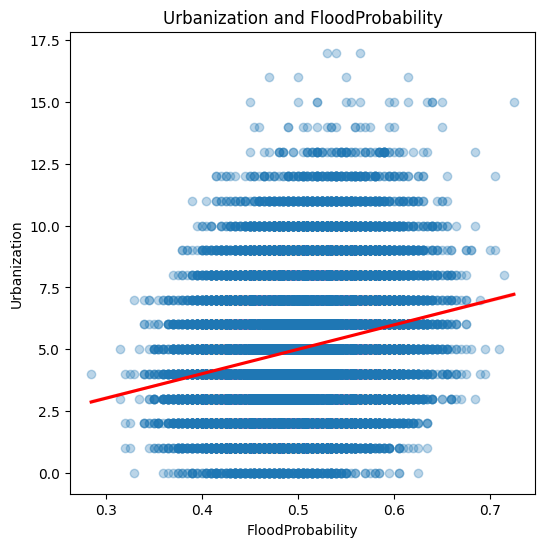

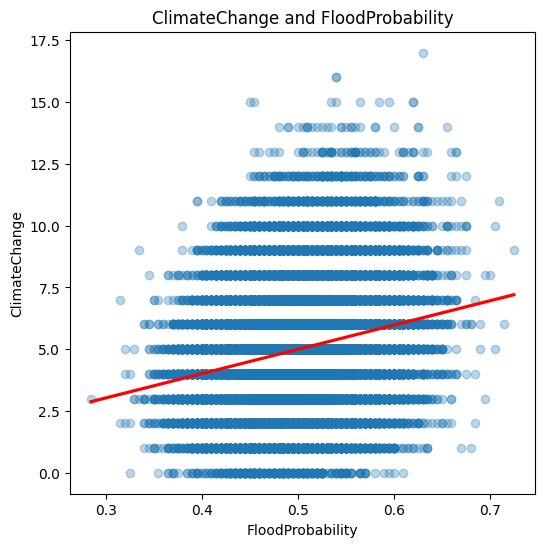

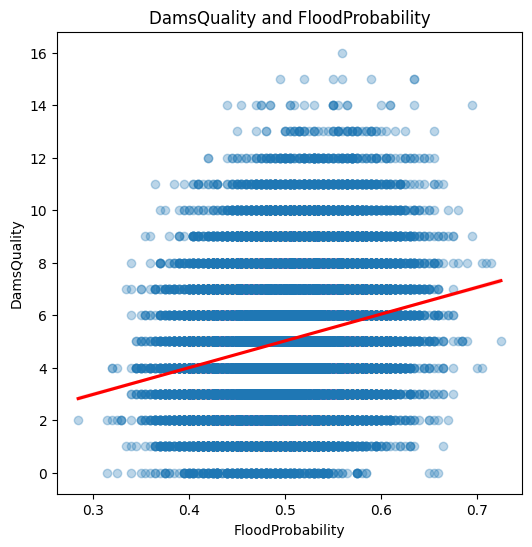

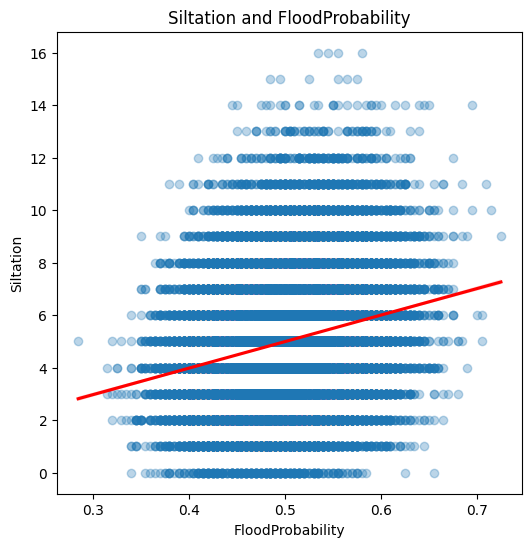

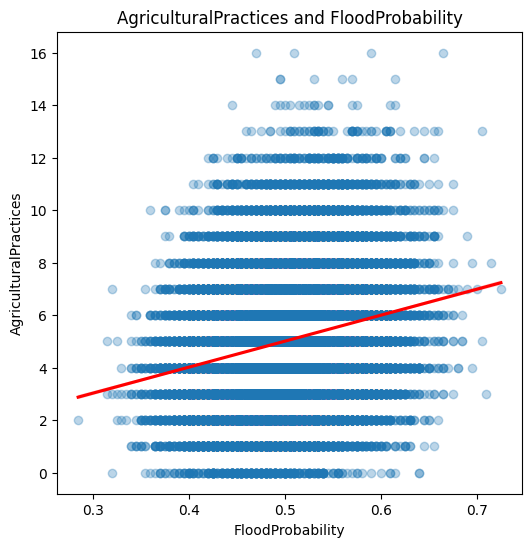

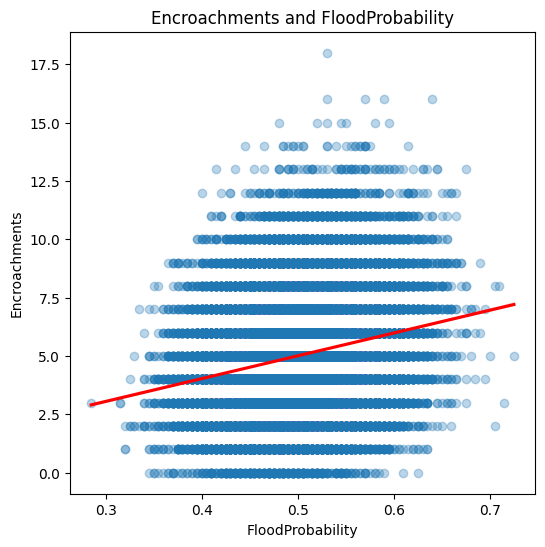

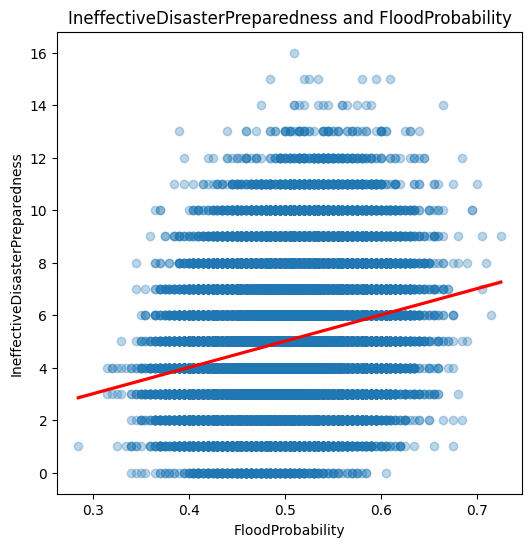

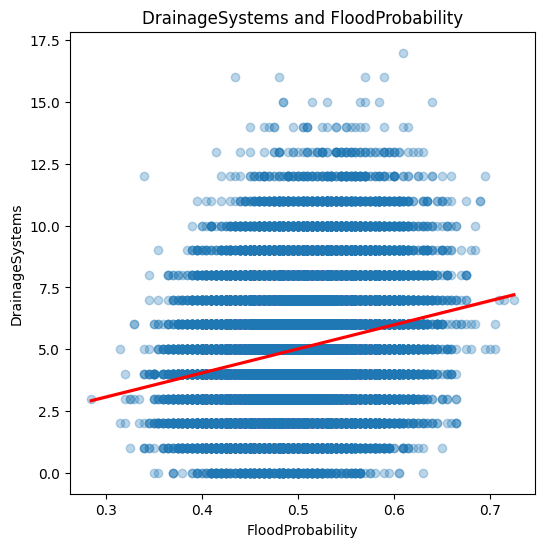

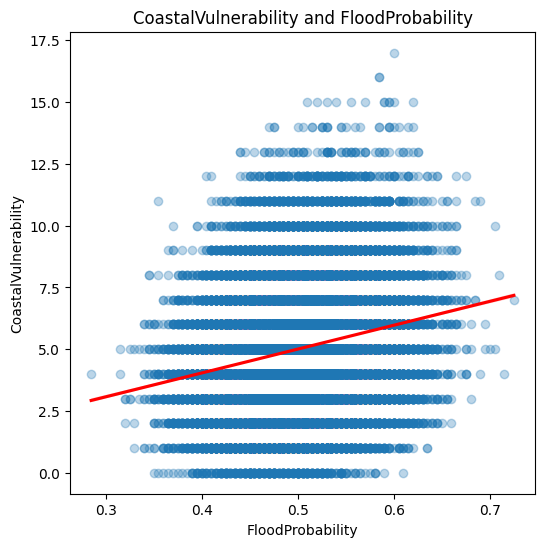

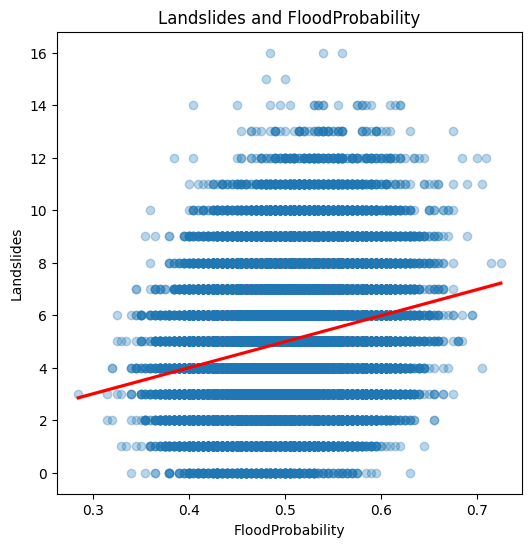

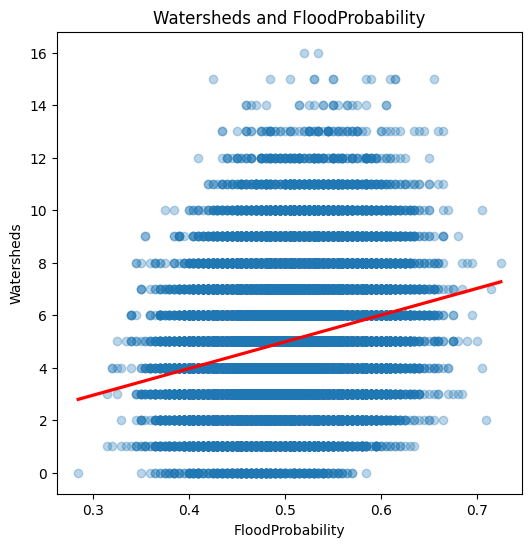

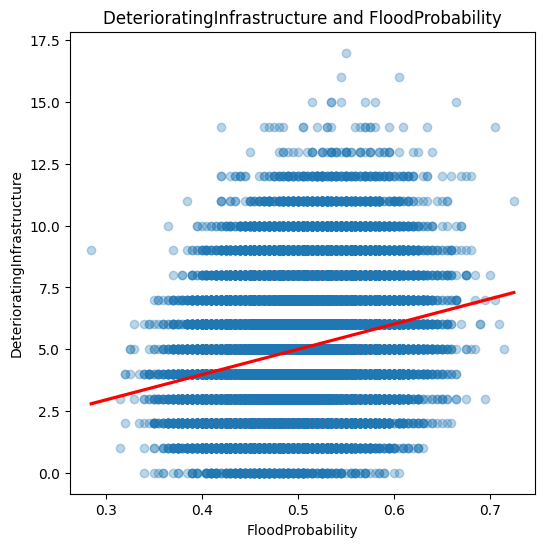

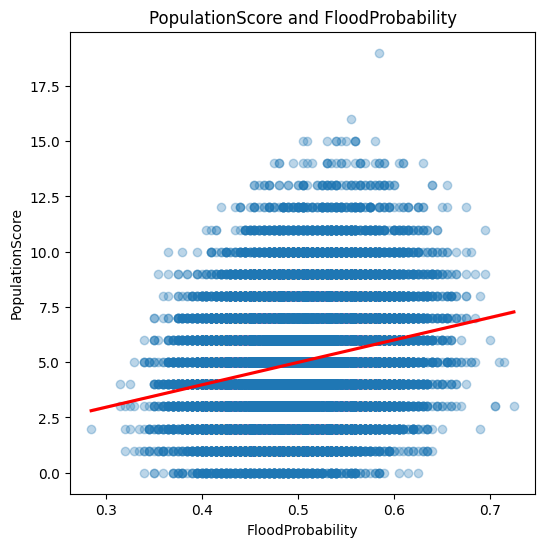

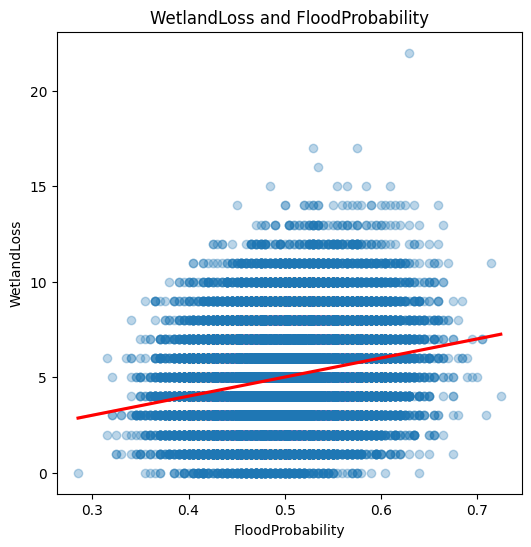

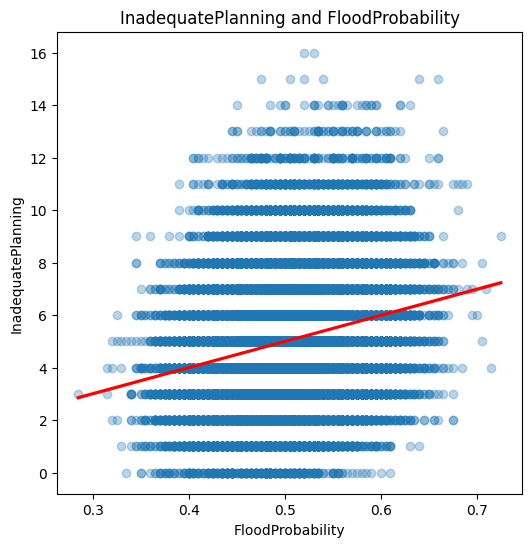

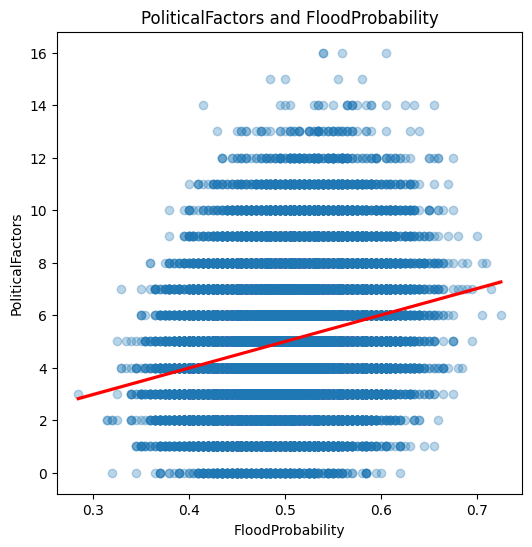

In [11]:
for col in df.columns:
    if col != 'FloodProbability':
        plt.figure(figsize=(6,6))
        sns.regplot(data=df, x='FloodProbability', y=col,
                    scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
        plt.title(f"{col} and FloodProbability")
        plt.show()

**In above pictures we can see a comparision between target variable floodprediction and other features . The distributions were very close to others . It means the data is already encoded and preprocessed**

# DATA CLEANING

**Data cleaning is a step where we see is there any problem in our data. The problem can be an outlier , duplicate row , missing values, false inputs etc . We have to overcome from this problem for making a better model**

In [12]:
# i dont want to make any change in my real dataset
# so i am copying the dataset

df_c = df.copy()

In [13]:
df_c.isnull().any()

MonsoonIntensity                   False
TopographyDrainage                 False
RiverManagement                    False
Deforestation                      False
Urbanization                       False
ClimateChange                      False
DamsQuality                        False
Siltation                          False
AgriculturalPractices              False
Encroachments                      False
IneffectiveDisasterPreparedness    False
DrainageSystems                    False
CoastalVulnerability               False
Landslides                         False
Watersheds                         False
DeterioratingInfrastructure        False
PopulationScore                    False
WetlandLoss                        False
InadequatePlanning                 False
PoliticalFactors                   False
FloodProbability                   False
dtype: bool

In [14]:
df_c.duplicated().any()

np.False_

In [15]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

**The good news is that my dataset has no missing values and duplicate rows and there is also no problem on data types. so i dont need to do any change on my dataset**

# Data Preprocessing

In [16]:
# now its time to split the data as my data is already preprossed
from sklearn.model_selection import train_test_split

X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation

In [18]:
from sklearn.linear_model import LinearRegression

# Model initialize
lr = LinearRegression()

# Train
lr.fit(X_train_scaled, y_train)

# Prediction
y_pred = lr.predict(X_test_scaled)

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
r2


1.0

In [20]:
train_r2 = lr.score(X_train_scaled, y_train)
test_r2 = lr.score(X_test_scaled, y_test)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 1.0
Test R² : 1.0


In [21]:
import numpy as np

y_pred_lr = lr.predict(X_test_scaled)

print("Max Error:", np.max(np.abs(y_test - y_pred_lr)))
print("Mean Error:", np.mean(np.abs(y_test - y_pred_lr)))

Max Error: 4.440892098500626e-16
Mean Error: 8.33444424586105e-17


In [22]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

y_pred_bag = bagging.predict(X_test)

print("R²:", r2_score(y_test, y_pred_bag))

R²: 0.7292329075831683


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R²:", r2_score(y_test, y_pred_rf))

R²: 0.7294957103200915


In [24]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

print("Ridge R2:", ridge.score(X_test_scaled, y_test))

Ridge R2: 0.9999999993783039


**The dataset exhibits an almost perfectly linear relationship between features and target variable. Linear models (Linear Regression and Ridge Regression) achieve near-perfect predictive performance (R² ≈ 1.0), indicating minimal noise and high determinism in the data generation process. In contrast, tree-based ensemble methods show comparatively lower performance due to their piecewise approximation nature**

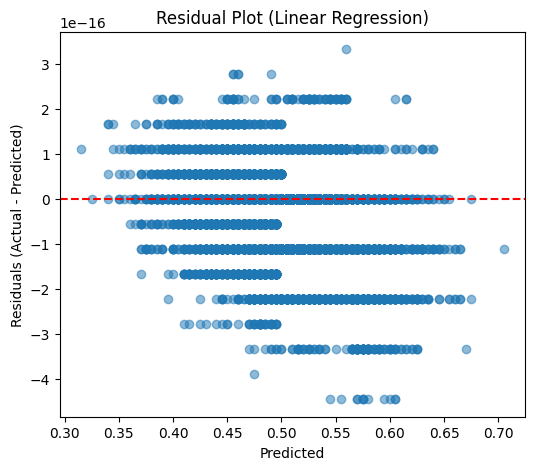

In [25]:
y_pred = lr.predict(X_test_scaled)

residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression)")
plt.show()

**Residuals are approximately zero across all predictions, confirming that the model captures the underlying data distribution almost perfectly.**

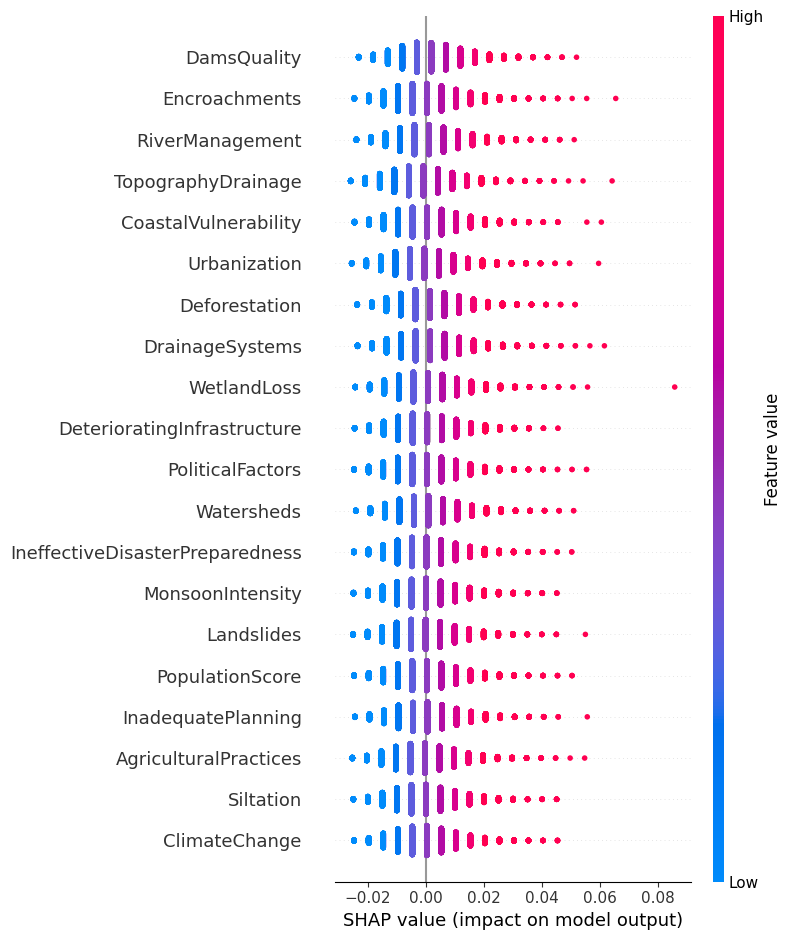

In [26]:
import shap

# model
explainer = shap.LinearExplainer(lr, X_train_scaled)

shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_train.columns)

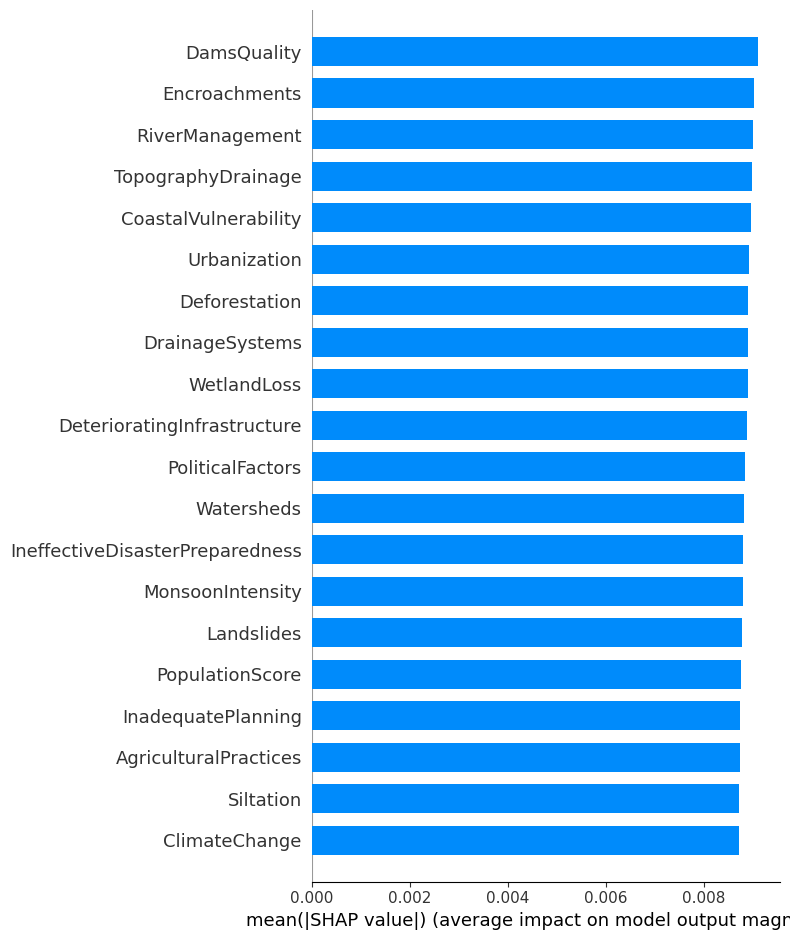

In [27]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_train.columns, plot_type="bar")

**SHAP analysis indicates that the target variable is influenced by a linear combination of all features, with relatively balanced feature contributions.**

# FINAL SUMMARY

**In this project, the Kaggle Flood Prediction dataset was used to build and evaluate multiple regression models. Linear Regression and Ridge Regression achieved near-perfect performance (R² ≈ 1.0) with almost zero prediction error, indicating a highly strong linear relationship between the input features and the target variable (FloodProbability). In contrast, tree-based ensemble models such as Random Forest and Bagging Regressor performed relatively lower (R² ≈ 0.72), suggesting that the dataset does not contain complex non-linear patterns. Residual analysis showed values close to zero, and SHAP analysis confirmed that all features contribute in a largely linear and proportional manner. Overall, the dataset appears to be highly deterministic in nature, where linear models are the most suitable approach for accurate prediction.**